# Lời giải mẫu: Chuỗi bài thực hành MLP

Notebook này là lời giải mẫu cho 6 hoạt động. Sinh viên có thể chạy từng phần độc lập.  
Các thuật ngữ quan trọng được viết theo dạng tiếng Việt kèm tiếng Anh trong ngoặc.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
# Giới hạn số luồng để notebook chạy nhanh và ổn định trên máy cá nhân/lab.
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path('../datasets')

def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

def print_metrics_table(rows):
    display(pd.DataFrame(rows).set_index('model').round(4))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Hàm hỗ trợ: MLP PyTorch cho hồi quy

In [2]:
class MLPRegressorTorch(nn.Module):
    def __init__(self, input_dim, hidden_layers=(16, 16), activation='relu'):
        super().__init__()
        acts = {
            'relu': nn.ReLU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid,
            'linear': nn.Identity,
        }
        if activation not in acts:
            raise ValueError(f'activation không hỗ trợ: {activation}')
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(acts[activation]())
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
        self.hidden_layers = hidden_layers
        self.activation_name = activation
    def forward(self, x):
        return self.net(x)

def train_torch_model(X_train, y_train, X_test=None, y_test=None, hidden_layers=(16,16), activation='relu', lr=0.01, epochs=100, checkpoints=None):
    """Huấn luyện MLP bằng full-batch Adam để notebook chạy nhanh trong lớp học."""
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    Xtr = scaler_x.fit_transform(X_train)
    ytr = scaler_y.fit_transform(y_train.reshape(-1,1))
    Xte = scaler_x.transform(X_test) if X_test is not None else None
    yte = scaler_y.transform(y_test.reshape(-1,1)) if y_test is not None else None

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.float32)
    Xte_t = torch.tensor(Xte, dtype=torch.float32) if Xte is not None else None
    yte_t = torch.tensor(yte, dtype=torch.float32) if yte is not None else None

    model = MLPRegressorTorch(X_train.shape[1], hidden_layers, activation)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {'epoch': [], 'train_loss': [], 'test_loss': [], 'grad_norm': []}
    saved_states = {}
    checkpoints = set(checkpoints or [])
    if 0 in checkpoints:
        saved_states[0] = {k: v.detach().clone() for k, v in model.state_dict().items()}

    for epoch in range(1, epochs+1):
        model.train()
        opt.zero_grad()
        pred = model(Xtr_t)
        loss = loss_fn(pred, ytr_t)
        loss.backward()
        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.detach().norm().item()**2
        grad_norm = total_norm**0.5
        opt.step()

        if epoch == 1 or epoch % 10 == 0 or epoch in checkpoints:
            model.eval()
            with torch.no_grad():
                train_loss = loss_fn(model(Xtr_t), ytr_t).item()
                test_loss = loss_fn(model(Xte_t), yte_t).item() if Xte_t is not None else np.nan
            history['epoch'].append(epoch)
            history['train_loss'].append(train_loss)
            history['test_loss'].append(test_loss)
            history['grad_norm'].append(grad_norm)
        if epoch in checkpoints:
            saved_states[epoch] = {k: v.detach().clone() for k, v in model.state_dict().items()}
    return model, scaler_x, scaler_y, pd.DataFrame(history), saved_states

def predict_torch(model, scaler_x, scaler_y, X):
    model.eval()
    Xt = torch.tensor(scaler_x.transform(X), dtype=torch.float32)
    with torch.no_grad():
        yp = model(Xt).numpy()
    return scaler_y.inverse_transform(yp).ravel()

# Hoạt động 1 - So sánh hồi quy tuyến tính, đa thức và MLP trên dữ liệu phi tuyến 1D

In [3]:
df = pd.read_csv(DATA_DIR/'activity_01_piecewise_nonlinear_1d.csv')
X = df[['x']].values
y = df['y'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)

models = {
    'Linear': LinearRegression(),
    'Poly degree 2': Pipeline([('poly', PolynomialFeatures(2)), ('lin', LinearRegression())]),
    'Poly degree 3': Pipeline([('poly', PolynomialFeatures(3)), ('lin', LinearRegression())]),
    'Poly degree 5 + Ridge': Pipeline([('poly', PolynomialFeatures(5)), ('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    'Poly degree 5 + Lasso': Pipeline([('poly', PolynomialFeatures(5)), ('scaler', StandardScaler()), ('lasso', Lasso(alpha=0.01, max_iter=10000))]),
    'Poly degree 5 + ElasticNet': Pipeline([('poly', PolynomialFeatures(5)), ('scaler', StandardScaler()), ('enet', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))])
}
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({'model': name, **metrics(y_test, pred)})

mlp, sx, sy, hist, _ = train_torch_model(X_train, y_train, X_test, y_test, hidden_layers=(32,32), activation='relu', lr=0.01, epochs=120)
pred_mlp = predict_torch(mlp, sx, sy, X_test)
rows.append({'model': 'MLP [32,32] ReLU', **metrics(y_test, pred_mlp)})
print_metrics_table(rows)

,MSE,RMSE,MAE,R2
model,,,,
Linear,2.6381,1.6242,1.3026,0.3029
Poly degree 2,1.7903,1.3380,1.1350,0.5269
Poly degree 3,0.7799,0.8831,0.6941,0.7939
Poly degree 5 + Ridge,0.7715,0.8784,0.6887,0.7961
Poly degree 5 + Lasso,0.7672,0.8759,0.6851,0.7973
Poly degree 5 + ElasticNet,0.7898,0.8887,0.7005,0.7913
"MLP [32,32] ReLU",0.3682,0.6068,0.4377,0.9027


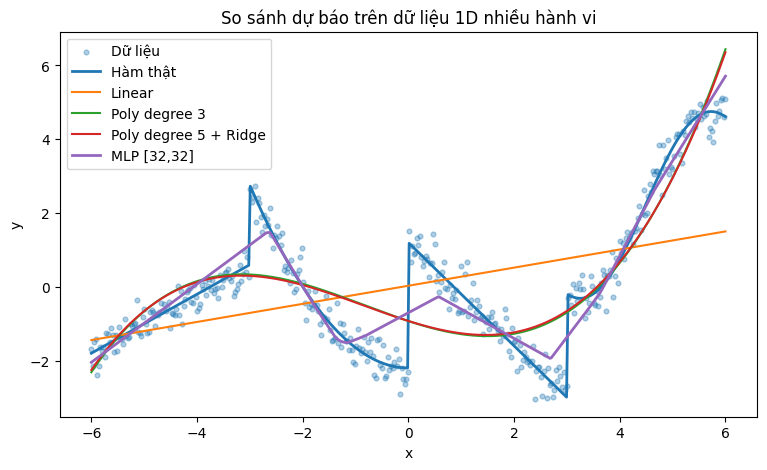

In [4]:
# Vẽ đường dự báo
x_grid = np.linspace(df.x.min(), df.x.max(), 500).reshape(-1,1)
plt.figure(figsize=(9,5))
plt.scatter(df['x'], df['y'], s=12, alpha=0.35, label='Dữ liệu')
plt.plot(df['x'], df['y_clean'], linewidth=2, label='Hàm thật')
for name, model in models.items():
    if name in ['Linear', 'Poly degree 3', 'Poly degree 5 + Ridge']:
        plt.plot(x_grid.ravel(), model.predict(x_grid), label=name)
plt.plot(x_grid.ravel(), predict_torch(mlp, sx, sy, x_grid), linewidth=2, label='MLP [32,32]')
plt.xlabel('x'); plt.ylabel('y'); plt.title('So sánh dự báo trên dữ liệu 1D nhiều hành vi')
plt.legend(); plt.show()

# Hoạt động 2 - Trực quan hóa nơ-ron trong MLP một lớp ẩn

In [5]:
df2 = pd.read_csv(DATA_DIR/'activity_02_relu_basis_1d.csv')
X = df2[['x']].values
y = df2['y'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
mlp1, sx1, sy1, hist1, _ = train_torch_model(X_train, y_train, X_test, y_test, hidden_layers=(8,), activation='relu', lr=0.01, epochs=120)
print('Số tham số:', count_parameters(mlp1))
print(pd.Series(metrics(y_test, predict_torch(mlp1, sx1, sy1, X_test))).round(4))

Số tham số: 25
MSE     0.2783
RMSE    0.5275
MAE     0.4289
R2      0.8737
dtype: float64


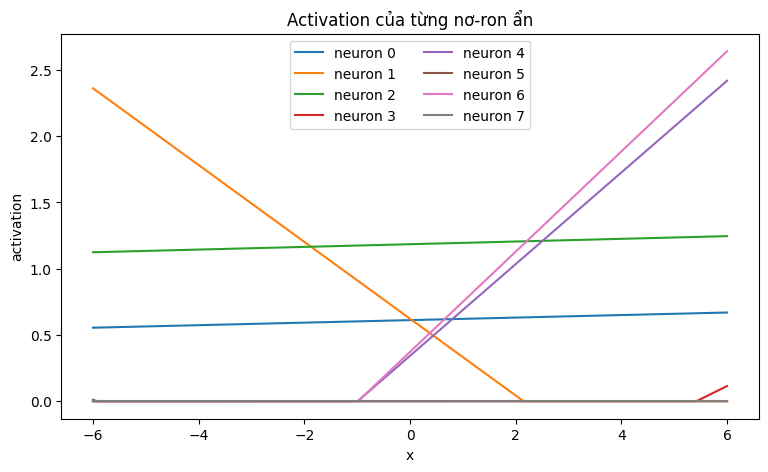

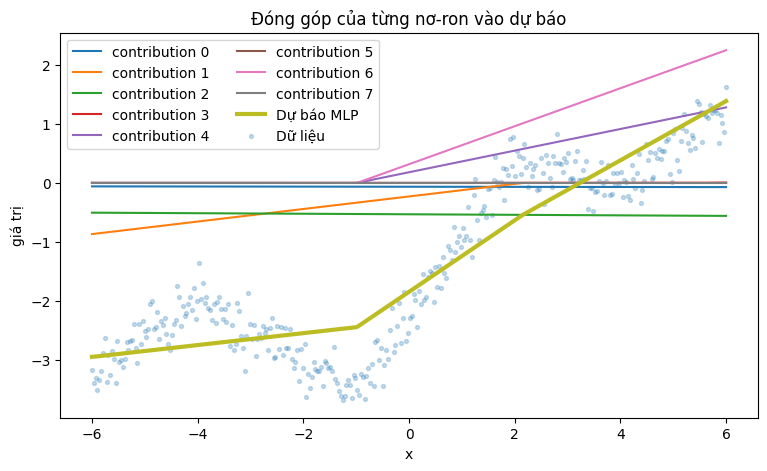

In [6]:
# Trích xuất z, activation a, và contribution của lớp ẩn đầu tiên
x_grid = np.linspace(df2.x.min(), df2.x.max(), 500).reshape(-1,1)
Xt = torch.tensor(sx1.transform(x_grid), dtype=torch.float32)
linear1 = mlp1.net[0]
act1 = mlp1.net[1]
out_layer = mlp1.net[2]
with torch.no_grad():
    z = linear1(Xt).numpy()
    a = act1(linear1(Xt)).numpy()
    y_scaled = mlp1(Xt).numpy()
    y_pred = sy1.inverse_transform(y_scaled).ravel()
    out_w = out_layer.weight.detach().numpy().ravel()
    out_b = out_layer.bias.detach().numpy()[0]
    contributions_scaled = a * out_w
    contributions = contributions_scaled * sy1.scale_[0]

plt.figure(figsize=(9,5))
for j in range(a.shape[1]):
    plt.plot(x_grid.ravel(), a[:,j], label=f'neuron {j}')
plt.title('Activation của từng nơ-ron ẩn')
plt.xlabel('x'); plt.ylabel('activation'); plt.legend(ncol=2); plt.show()

plt.figure(figsize=(9,5))
for j in range(contributions.shape[1]):
    plt.plot(x_grid.ravel(), contributions[:,j], label=f'contribution {j}')
plt.plot(x_grid.ravel(), y_pred, linewidth=3, label='Dự báo MLP')
plt.scatter(df2.x, df2.y, s=8, alpha=0.25, label='Dữ liệu')
plt.title('Đóng góp của từng nơ-ron vào dự báo')
plt.xlabel('x'); plt.ylabel('giá trị'); plt.legend(ncol=2); plt.show()

# Hoạt động 3 - Thí nghiệm kiến trúc mạng

In [7]:
df3 = pd.read_csv(DATA_DIR/'activity_03_architecture_experiment_1d.csv')
train = df3[df3['split']=='train']
test = df3[df3['split']=='test']
X_train, y_train = train[['x']].values, train['y'].values
X_test, y_test = test[['x']].values, test['y'].values
configs = [
    ('A [2] ReLU', (2,), 'relu'),
    ('B [8] ReLU', (8,), 'relu'),
    ('C [32] ReLU', (32,), 'relu'),
    ('D [8,8] ReLU', (8,8), 'relu'),
    ('E [16,16,16] ReLU', (16,16,16), 'relu'),
    ('F [16,16] tanh', (16,16), 'tanh'),
    ('G [16,16] linear', (16,16), 'linear'),
]
rows = []
trained = {}
for name, hidden, act in configs:
    model, sx, sy, hist, _ = train_torch_model(X_train, y_train, X_test, y_test, hidden_layers=hidden, activation=act, lr=0.01, epochs=100)
    pred_train = predict_torch(model, sx, sy, X_train)
    pred_test = predict_torch(model, sx, sy, X_test)
    rows.append({'model': name, 'params': count_parameters(model), 'train_RMSE': np.sqrt(mean_squared_error(y_train, pred_train)), 'test_RMSE': np.sqrt(mean_squared_error(y_test, pred_test)), 'test_MAE': mean_absolute_error(y_test, pred_test)})
    trained[name] = (model, sx, sy, hist)
display(pd.DataFrame(rows).round(4))

,model,params,train_RMSE,test_RMSE,test_MAE
0,A [2] ReLU,7,1.7592,1.6961,1.3108
1,B [8] ReLU,25,1.2038,1.1956,0.9391
2,C [32] ReLU,97,0.9400,0.8651,0.6785
3,"D [8,8] ReLU",97,1.0036,0.9117,0.7058
4,"E [16,16,16] ReLU",593,0.8165,0.7761,0.6100
5,"F [16,16] tanh",321,1.0831,1.0416,0.8294
6,"G [16,16] linear",321,1.7546,1.6958,1.3262


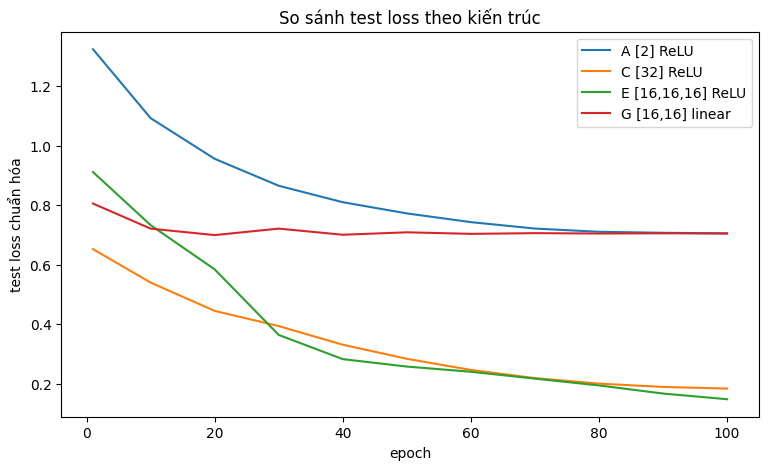

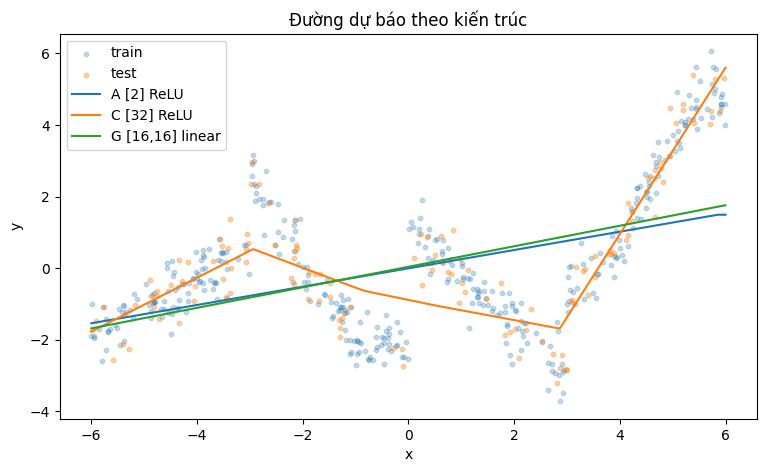

In [8]:
# Loss curve và prediction curve của một số mô hình
plt.figure(figsize=(9,5))
for name in ['A [2] ReLU', 'C [32] ReLU', 'E [16,16,16] ReLU', 'G [16,16] linear']:
    hist = trained[name][3]
    plt.plot(hist['epoch'], hist['test_loss'], label=name)
plt.xlabel('epoch'); plt.ylabel('test loss chuẩn hóa'); plt.title('So sánh test loss theo kiến trúc')
plt.legend(); plt.show()

x_grid = np.linspace(df3.x.min(), df3.x.max(), 500).reshape(-1,1)
plt.figure(figsize=(9,5))
plt.scatter(train.x, train.y, s=10, alpha=0.25, label='train')
plt.scatter(test.x, test.y, s=10, alpha=0.35, label='test')
for name in ['A [2] ReLU', 'C [32] ReLU', 'G [16,16] linear']:
    model, sx, sy, _ = trained[name]
    plt.plot(x_grid.ravel(), predict_torch(model, sx, sy, x_grid), label=name)
plt.legend(); plt.title('Đường dự báo theo kiến trúc'); plt.xlabel('x'); plt.ylabel('y'); plt.show()

# Hoạt động 4 - Quan sát quá trình học qua epoch, gradient và checkpoint

,epoch,train_loss,test_loss,grad_norm
12,110,0.029236,0.029236,0.011051
13,120,0.028745,0.028745,0.008514
14,130,0.028448,0.028448,0.007078
15,140,0.028176,0.028176,0.006975
16,150,0.027923,0.027923,0.006066


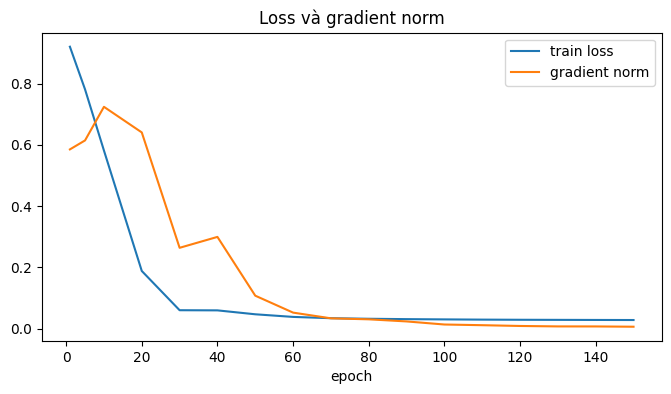

In [9]:
df4 = pd.read_csv(DATA_DIR/'activity_04_learning_dynamics_1d.csv')
X = df4[['x']].values
y = df4['y'].values
checkpoints = [0, 1, 5, 10, 50, 100, 150]
model4, sx4, sy4, hist4, states = train_torch_model(X, y, X, y, hidden_layers=(16,16), activation='relu', lr=0.01, epochs=150, checkpoints=checkpoints)
display(hist4.tail())

plt.figure(figsize=(8,4))
plt.plot(hist4['epoch'], hist4['train_loss'], label='train loss')
plt.plot(hist4['epoch'], hist4['grad_norm'], label='gradient norm')
plt.xlabel('epoch'); plt.title('Loss và gradient norm'); plt.legend(); plt.show()

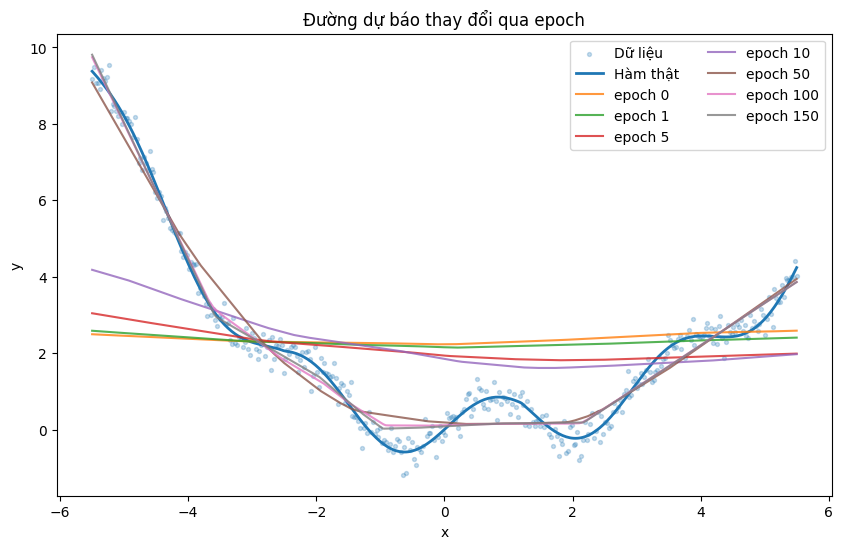

In [10]:
# Dự báo tại các checkpoint
x_grid = np.linspace(df4.x.min(), df4.x.max(), 500).reshape(-1,1)
plt.figure(figsize=(10,6))
plt.scatter(df4.x, df4.y, s=8, alpha=0.25, label='Dữ liệu')
plt.plot(df4.x, df4.y_clean, linewidth=2, label='Hàm thật')
for ep in checkpoints:
    temp = MLPRegressorTorch(1, (16,16), 'relu')
    temp.load_state_dict(states[ep])
    yp = predict_torch(temp, sx4, sy4, x_grid)
    plt.plot(x_grid.ravel(), yp, label=f'epoch {ep}', alpha=0.8)
plt.legend(ncol=2); plt.title('Đường dự báo thay đổi qua epoch'); plt.xlabel('x'); plt.ylabel('y'); plt.show()

# Hoạt động 5 - MLP nhiều đầu vào và trực quan hóa bề mặt 2D

In [11]:
df5 = pd.read_csv(DATA_DIR/'activity_05_multivariate_surface_2d.csv')
train = df5[df5.split=='train']
test = df5[df5.split=='test']
X_train = train[['x1','x2']].values; y_train = train['y'].values
X_test = test[['x1','x2']].values; y_test = test['y'].values

lin2 = Pipeline([('scaler', StandardScaler()), ('lin', LinearRegression())])
poly2 = Pipeline([('poly', PolynomialFeatures(3)), ('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
lin2.fit(X_train, y_train)
poly2.fit(X_train, y_train)
mlp2, sx2, sy2, hist2, _ = train_torch_model(X_train, y_train, X_test, y_test, hidden_layers=(64,64), activation='relu', lr=0.005, epochs=120)

rows = []
for name, model in [('Linear', lin2), ('Polynomial degree 3 + Ridge', poly2)]:
    rows.append({'model': name, **metrics(y_test, model.predict(X_test))})
rows.append({'model': 'MLP [64,64]', **metrics(y_test, predict_torch(mlp2, sx2, sy2, X_test))})
print_metrics_table(rows)

,MSE,RMSE,MAE,R2
model,,,,
Linear,7.1824,2.6800,2.1448,0.7468
Polynomial degree 3 + Ridge,0.4864,0.6975,0.5765,0.9829
"MLP [64,64]",0.2649,0.5147,0.4123,0.9907


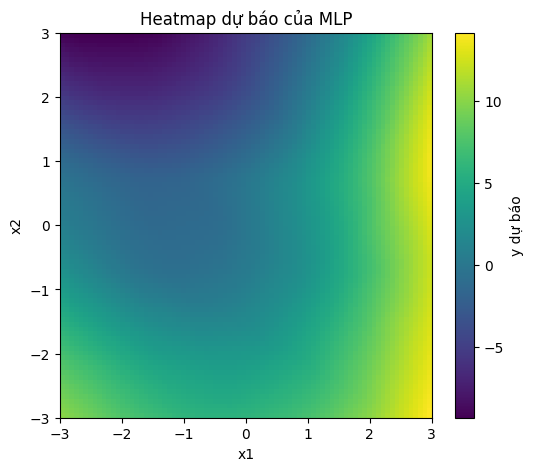

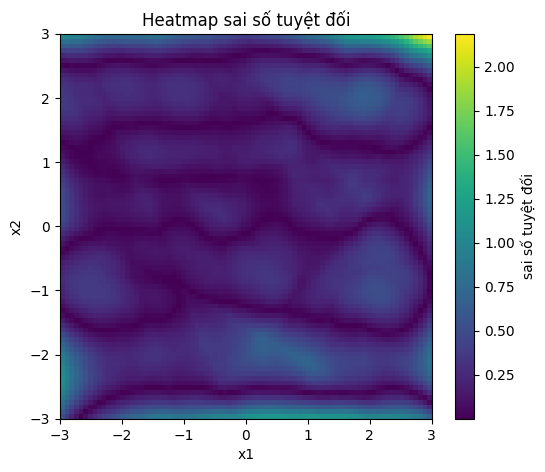

In [12]:
# Heatmap dự báo của MLP
x1g = np.linspace(-3, 3, 80)
x2g = np.linspace(-3, 3, 80)
xx, yy = np.meshgrid(x1g, x2g)
grid = np.c_[xx.ravel(), yy.ravel()]
zz_mlp = predict_torch(mlp2, sx2, sy2, grid).reshape(xx.shape)
zz_true = (2*xx - 1.5*yy + 0.8*xx**2 + np.sin(2*yy) + 0.5*xx*yy)

plt.figure(figsize=(6,5))
plt.imshow(zz_mlp, extent=[-3,3,-3,3], origin='lower', aspect='auto')
plt.colorbar(label='y dự báo')
plt.xlabel('x1'); plt.ylabel('x2'); plt.title('Heatmap dự báo của MLP'); plt.show()

plt.figure(figsize=(6,5))
plt.imshow(np.abs(zz_true-zz_mlp), extent=[-3,3,-3,3], origin='lower', aspect='auto')
plt.colorbar(label='sai số tuyệt đối')
plt.xlabel('x1'); plt.ylabel('x2'); plt.title('Heatmap sai số tuyệt đối'); plt.show()

In [13]:
# Gradient của y_hat theo x1, x2 tại một số điểm
sample = np.array([[0,0], [1,1], [-2,2], [2,-1]], dtype=float)
xs = torch.tensor(sx2.transform(sample), dtype=torch.float32, requires_grad=True)
ys = mlp2(xs)
ys.sum().backward()
# Gradient trong không gian đã chuẩn hóa; chia cho scale đầu vào và nhân scale y để đưa về đơn vị gốc gần đúng
input_grad_original_units = xs.grad.detach().numpy() * sy2.scale_[0] / sx2.scale_
pd.DataFrame(input_grad_original_units, columns=['dy_hat/dx1', 'dy_hat/dx2'], index=[str(s) for s in sample]).round(4)

,dy_hat/dx1,dy_hat/dx2
[0. 0.],2.3711,-0.0908
[1. 1.],4.2016,-1.2048
[-2. 2.],-0.2281,-3.5538
[ 2. -1.],4.9783,-1.3825


# Hoạt động 6 - Dữ liệu nhiều biến: Linear/Ridge/Lasso/Elastic Net/MLP

In [14]:
df6 = pd.read_csv(DATA_DIR/'activity_06_high_dimensional_mlp.csv')
features = [c for c in df6.columns if c.startswith('x')]
train = df6[df6.split=='train']; test = df6[df6.split=='test']
X_train = train[features].values; y_train = train['y'].values
X_test = test[features].values; y_test = test['y'].values

baseline_models = {
    'Linear': Pipeline([('scaler', StandardScaler()), ('lin', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    'Lasso': Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(alpha=0.03, max_iter=10000))]),
    'Elastic Net': Pipeline([('scaler', StandardScaler()), ('enet', ElasticNet(alpha=0.03, l1_ratio=0.5, max_iter=10000))])
}
rows = []
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    rows.append({'model': name, **metrics(y_test, model.predict(X_test))})
mlp6, sx6, sy6, hist6, _ = train_torch_model(X_train, y_train, X_test, y_test, hidden_layers=(64,32), activation='relu', lr=0.005, epochs=120)
rows.append({'model': 'MLP [64,32]', **metrics(y_test, predict_torch(mlp6, sx6, sy6, X_test))})
print_metrics_table(rows)

,MSE,RMSE,MAE,R2
model,,,,
Linear,1.6363,1.2792,0.9766,0.8162
Ridge,1.6358,1.2790,0.9765,0.8162
Lasso,1.5990,1.2645,0.9713,0.8203
Elastic Net,1.6114,1.2694,0.9744,0.8189
"MLP [64,32]",0.6579,0.8111,0.6337,0.9261


In [15]:
# Kiểm tra hệ số của Lasso
lasso = baseline_models['Lasso'].named_steps['lasso']
coef = pd.Series(lasso.coef_, index=features).sort_values(key=np.abs, ascending=False)
display(coef.to_frame('lasso_coefficient').round(4))

# Hoán vị đặc trưng (permutation importance) đơn giản cho MLP
base_rmse = np.sqrt(mean_squared_error(y_test, predict_torch(mlp6, sx6, sy6, X_test)))
importances = []
rng = np.random.default_rng(SEED)
for j, feat in enumerate(features):
    X_perm = X_test.copy()
    X_perm[:, j] = rng.permutation(X_perm[:, j])
    rmse_perm = np.sqrt(mean_squared_error(y_test, predict_torch(mlp6, sx6, sy6, X_perm)))
    importances.append({'feature': feat, 'rmse_increase': rmse_perm - base_rmse})
display(pd.DataFrame(importances).sort_values('rmse_increase', ascending=False).round(4))

,lasso_coefficient
x2,-2.0832
x1,1.5069
x5,0.5076
x7,-0.4305
x8,0.0886
x4,-0.0815
x6,0.0645
x12,-0.0040
x3,0.0000
x9,-0.0000


,feature,rmse_increase
1,x2,2.1899
0,x1,1.3336
2,x3,0.6141
5,x6,0.4887
3,x4,0.4764
4,x5,0.2517
6,x7,0.1977
8,x9,-0.0070
10,x11,-0.0090
9,x10,-0.0187
